In [ ]:
import datetime
import os
import pysr
import sympy
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn.functional as F
from IPython.display import display, Markdown

sys.path.append('../')
from pnam.utils.plot import *
from pnam.utils.sr import *
from pnam.wrapper import PNAMBase

In [2]:
def quantize(predictions, num_classes):
    predictions = torch.round(predictions * (num_classes - 1))
    predictions = torch.max(predictions, torch.zeros_like(predictions))
    predictions = torch.min(
        predictions, (num_classes - 1) * torch.ones_like(predictions)
    ).to(dtype=torch.long)
    return predictions

In [3]:
def accuracy(predictions, targets, num_classes):
    predictions = torch.tensor(predictions, dtype=torch.float)
    targets = targets.to(dtype=torch.long)
    predictions = quantize(predictions, num_classes)
    return torch.mean(
        (predictions == targets).float()
    ).detach().cpu().numpy().item()

In [4]:
# time = datetime.datetime.now().isoformat()
time = 'knot_theory_regress_pnam_w1e-3'

In [5]:
small_size = 16
large_size = 24
plt.rc('font', size=small_size)
plt.rc('axes', labelsize=large_size)

In [6]:
# Download data: https://colab.research.google.com/github/deepmind/mathematics_conjectures/blob/main/knot_theory.ipynb#scrollTo=l10N2ZbHu6Ob
data_path = '../../data/knot_theory_invariants.csv'
df = pd.read_csv(data_path)
X = df[df.keys()[1:-1]].to_numpy()
y = df['signature'].to_numpy()

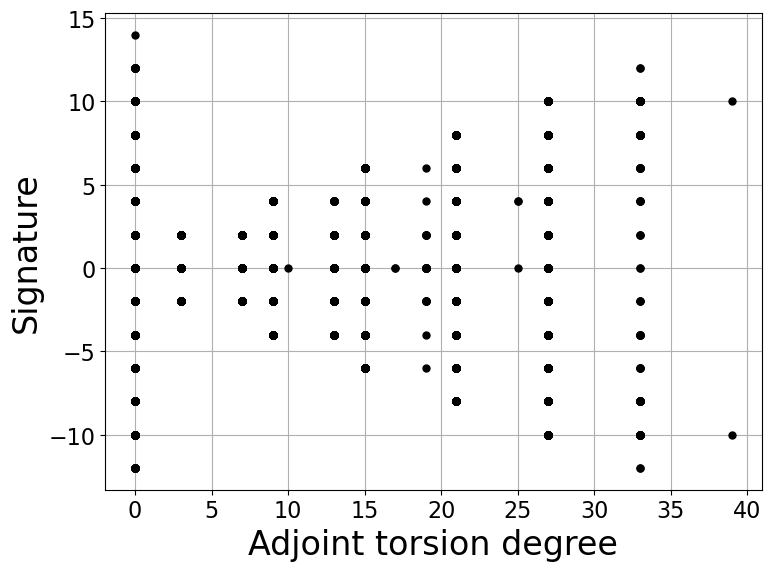

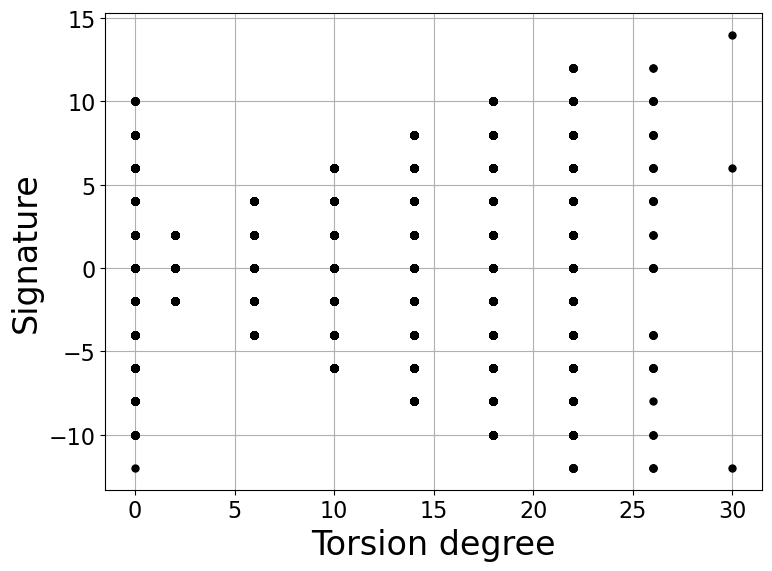

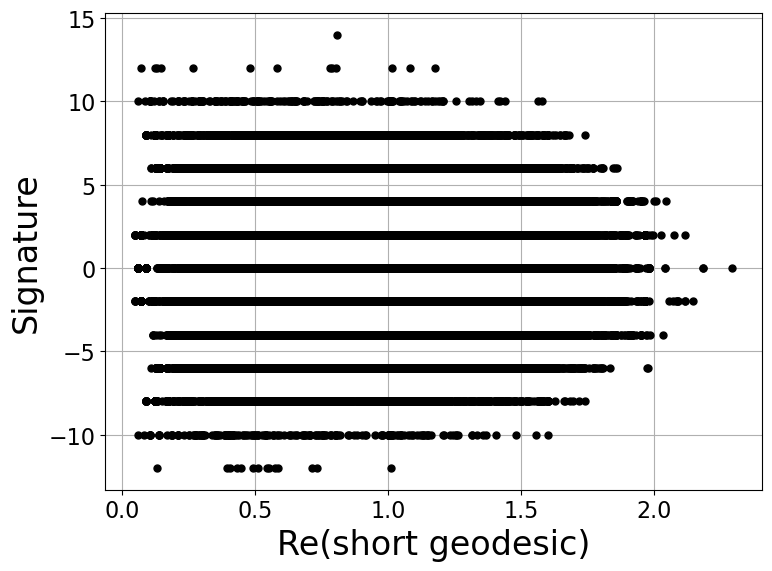

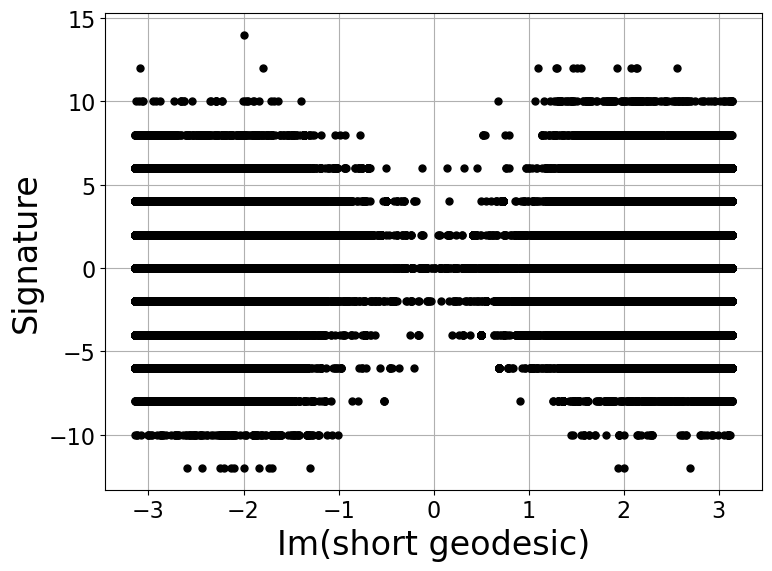

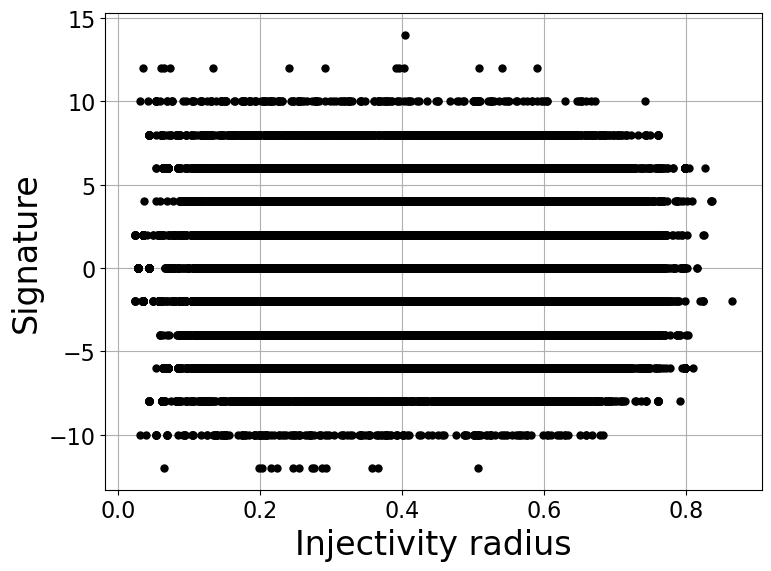

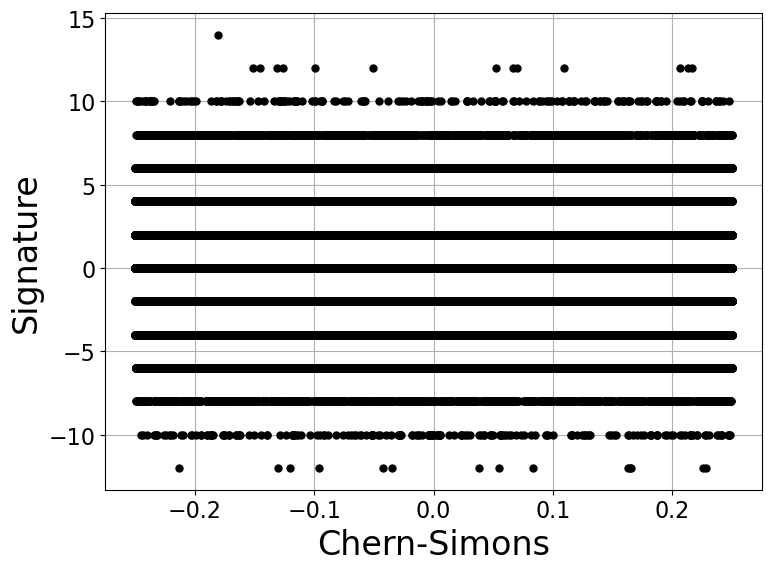

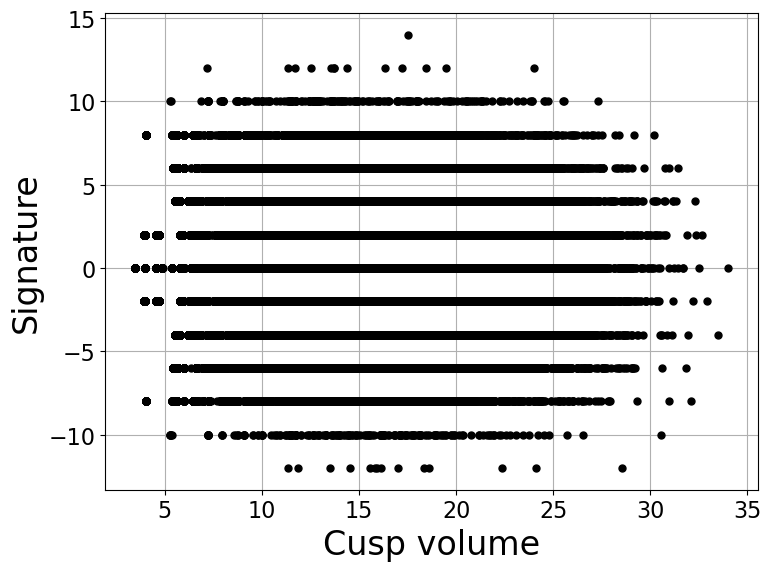

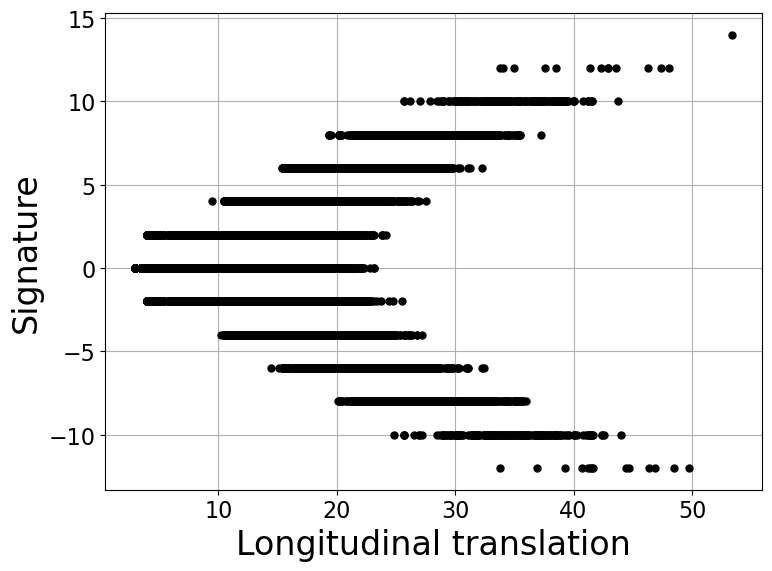

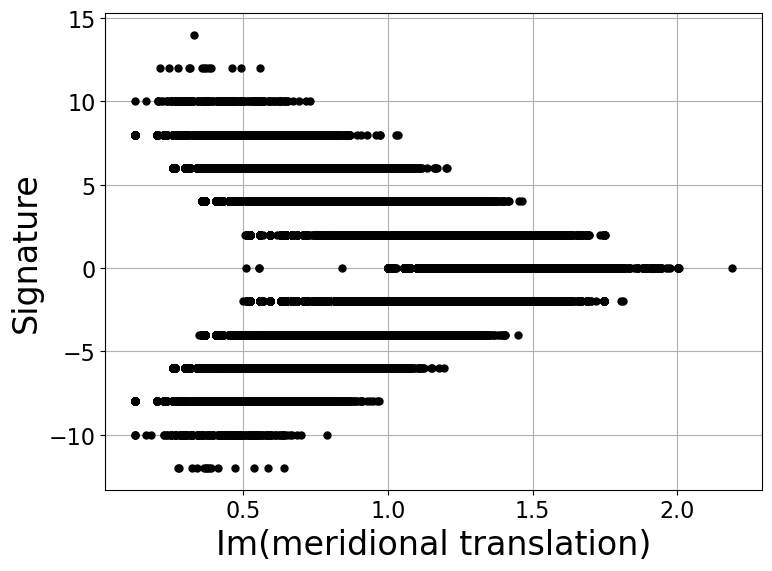

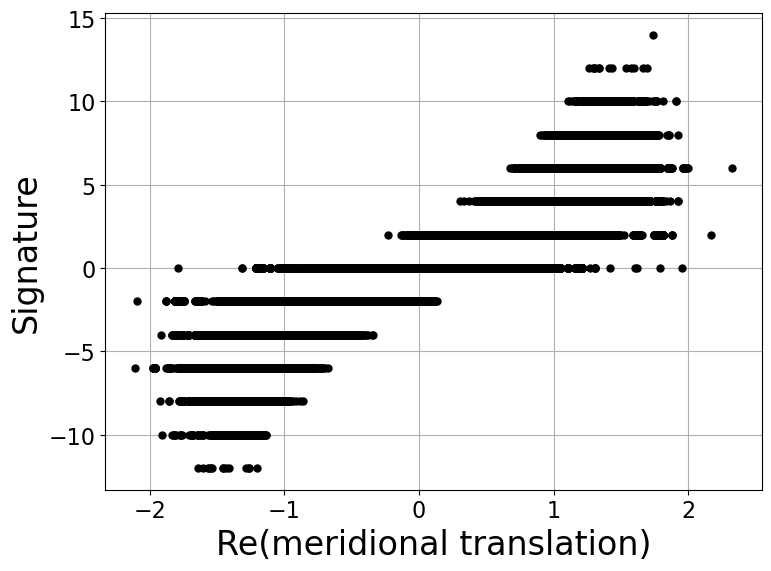

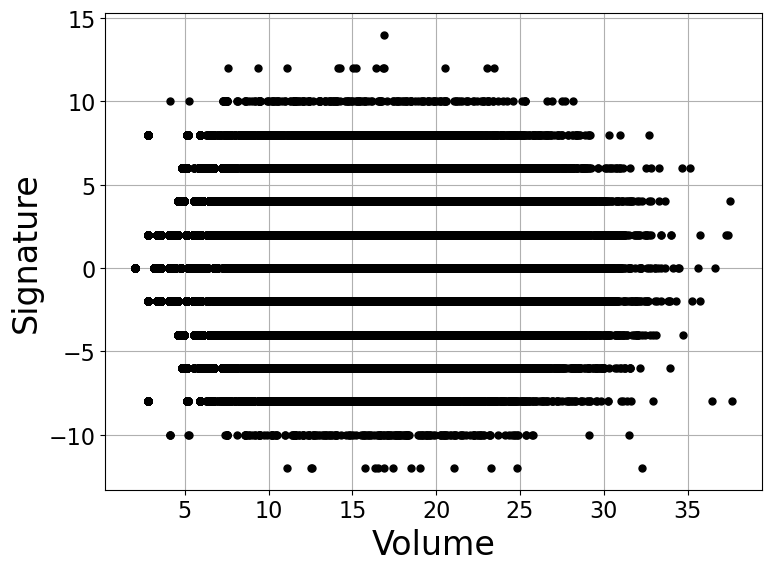

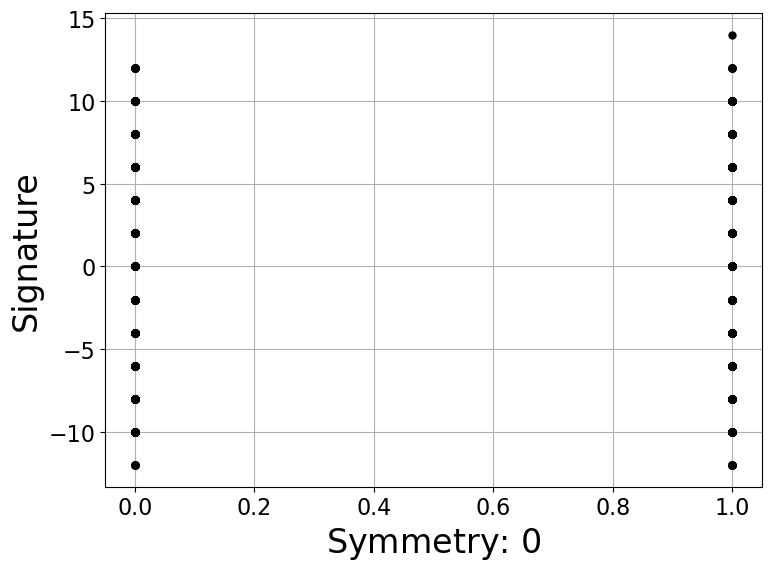

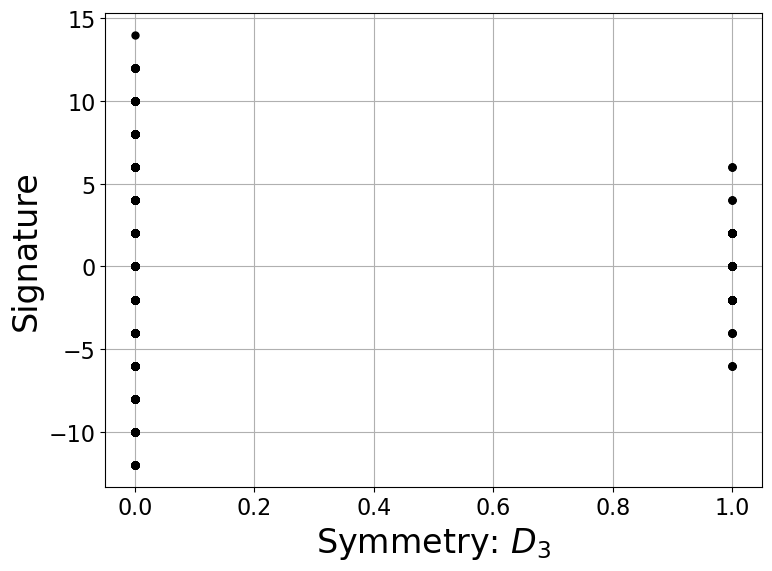

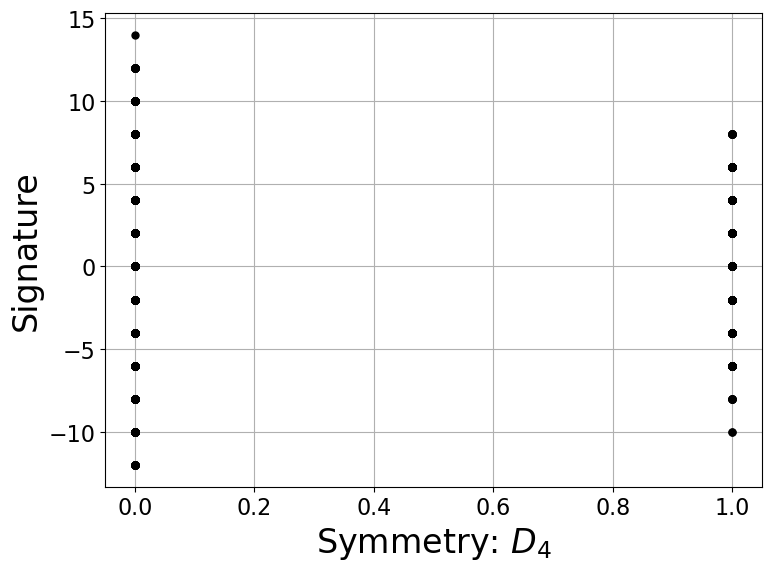

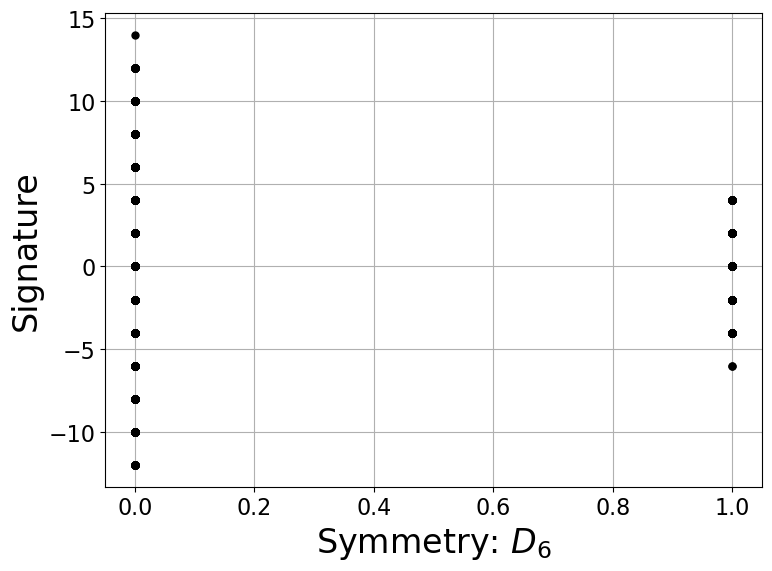

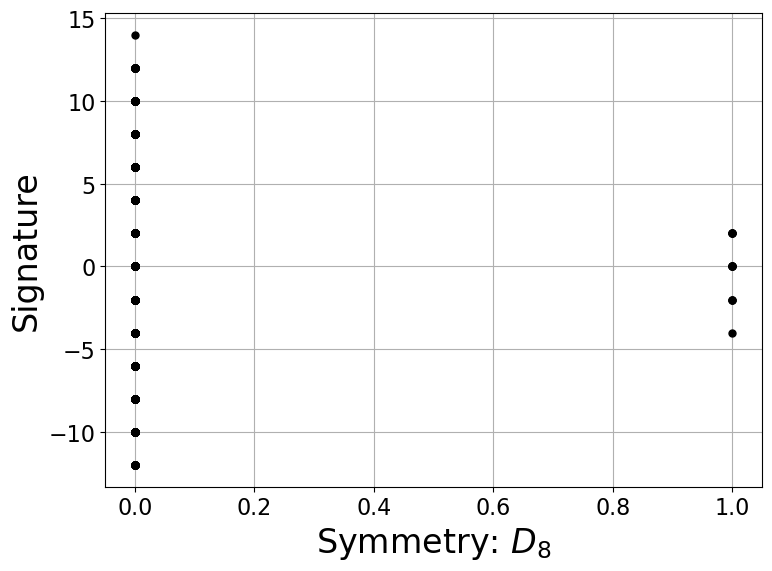

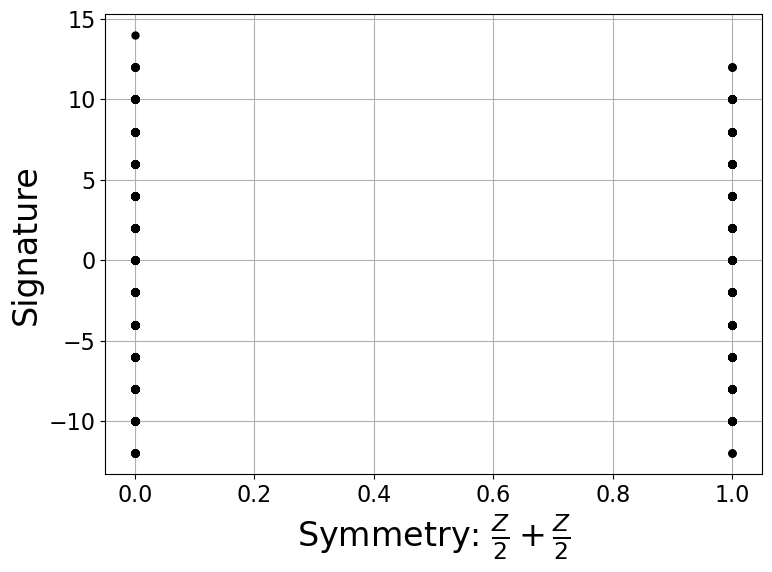

In [7]:
X_labels = [
    'Adjoint torsion degree',
    'Torsion degree',
    'Re(short geodesic)',
    'Im(short geodesic)',
    'Injectivity radius',
    'Chern-Simons',
    'Cusp volume',
    'Longitudinal translation',
    'Im(meridional translation)',
    'Re(meridional translation)',
    'Volume',
    'Symmetry: $0$',
    'Symmetry: $D_3$',
    'Symmetry: $D_4$',
    'Symmetry: $D_6$',
    'Symmetry: $D_8$',
    r'Symmetry: $\frac{Z}{2} + \frac{Z}{2}$'
]
plot_vars(X, y, X_labels=X_labels, y_labels=['Signature'])

In [8]:
# Normalize X
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean) / X_std

In [9]:
# Normalize y
min_signature = y.min()
max_signature = y.max()
y = (y - min_signature) / (max_signature - min_signature)
num_classes = int((max_signature - min_signature) / 2 + 1)

In [10]:
random_state = 42
train_ratio = 0.8
num_points = X.shape[0]
np.random.seed(random_state)
train_indices = np.random.choice(
    num_points, int(train_ratio * num_points), replace=False
)
test_indices = np.array(list(set(range(num_points)) - set(train_indices)))

In [11]:
X_train = torch.tensor(X[train_indices], dtype=torch.float)
X_test = torch.tensor(X[test_indices], dtype=torch.float)
y_train = torch.tensor(y[train_indices], dtype=torch.float)
y_test = torch.tensor(y[test_indices], dtype=torch.float)

In [12]:
pnam = True
num_inputs = X.shape[1]
proj_size = 8
num_networks = proj_size if proj_size > 0 else num_inputs
num_outputs = 1
metric = None
sobolev = False

model_idx = 9
weight_thresh = 0.01
proj_mat_idx = 3

sr = True
num_sr_points = 1000

In [13]:
model_pnam = PNAMBase(
    random_state=random_state,
    num_learners=10,
    pnam=pnam,
    std=0.,
    proj_size=proj_size,
    hidden_sizes=[64, 32],
    num_outputs=num_outputs,
    activation=F.silu,
    dropout=0.,
    feature_dropout=0.,
    device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
    regression=True,
    rot_reg=0.001,
    proj_reg=0.001,
    weight_reg=0.001,
    output_reg=0.001,
    l2_reg=0.001,
    verbose=False,
    metric=metric,
    scale=True,
    sobolev=sobolev,
    val_split=0.2,
    n_jobs=4,
    batch_size=256,
    log_dir=f'{time}/pnam',
    lr=0.001,
    decay_step=1,
    decay_rate=0.995,
    num_epochs=50,
    energy=False,
    patience=0  # Disable early stopping to keep last-epoch model
)

In [14]:
# model_pnam.fit(X_train, y_train)
model_pnam.load_checkpoints(f'{time}/pnam')

In [15]:
plot_dir = f'{time}/figures/{model_idx}'
os.makedirs(plot_dir, exist_ok=True)
print(f'Model index: {model_idx}')

Model index: 9


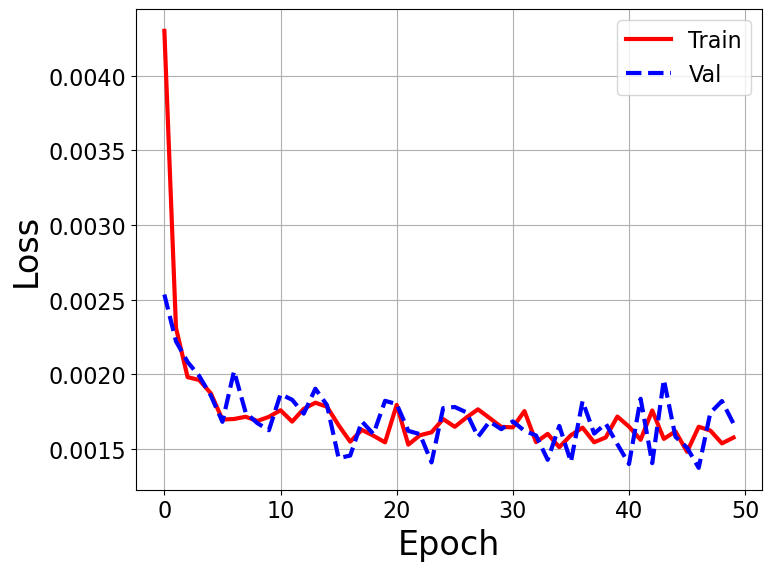

In [16]:
plot_loss_or_metric(
    time, model_idx, 'loss', semilogy=False
)

In [17]:
(
    preds_test,
    feats_out_test,
    feats_in_test,
    weight,
    bias,
    proj_mat,
    grad_in_test
) = model_pnam.predict(X_test, y_test, model_idx)
acc = accuracy(
    preds_test, y_test * (max_signature - min_signature) / 2, num_classes
)
print(f'Acc: {acc:.10f}')

Loss: 0.0007239826
Acc: 0.8513640761


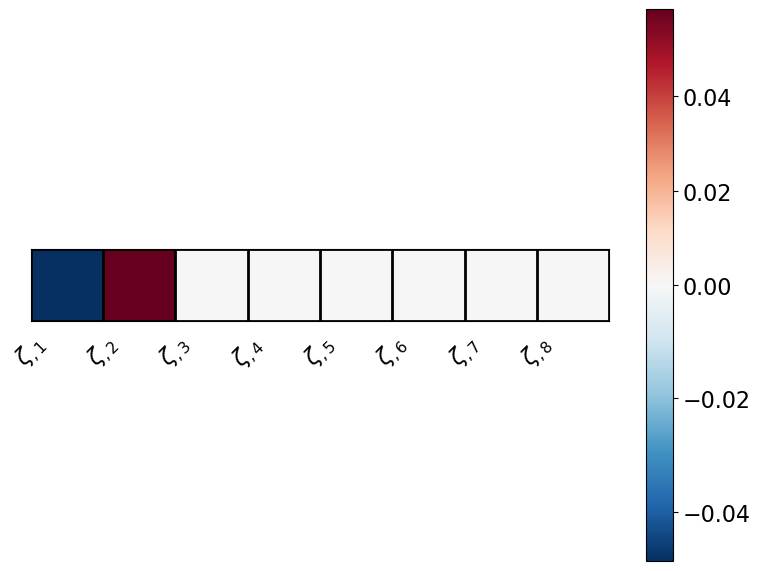

In [ ]:
plot_weight(
    weight,
    color=None,
    labels=[r'$\zeta_{,%s}$' % (i + 1) for i in range(num_networks)],
    colorbar=True
)

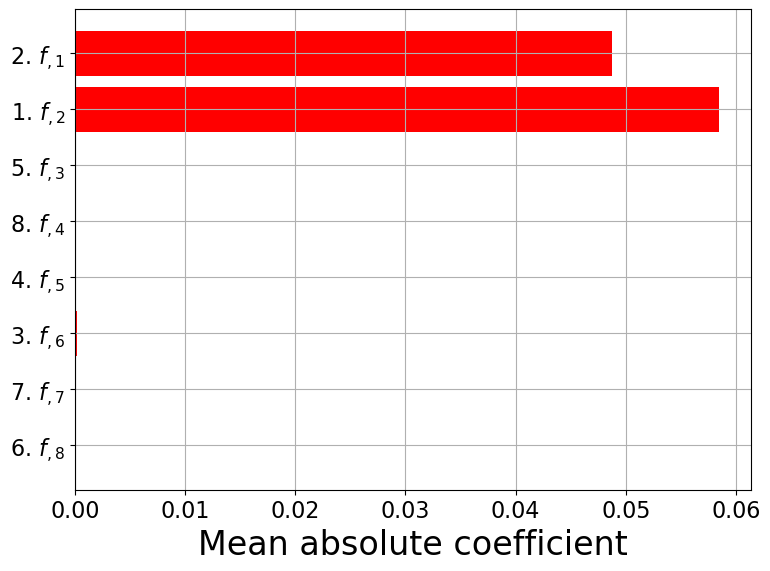

In [19]:
weight_mean = np.mean(abs(weight), axis=0)
plot_mean(
    weight_mean,
    labels=['$f_{,%s}$' % (i + 1) for i in range(num_networks)]
)

In [ ]:
for i in range(proj_size):
    if weight_mean[i] == 0:
        proj_mat[i] = 0.

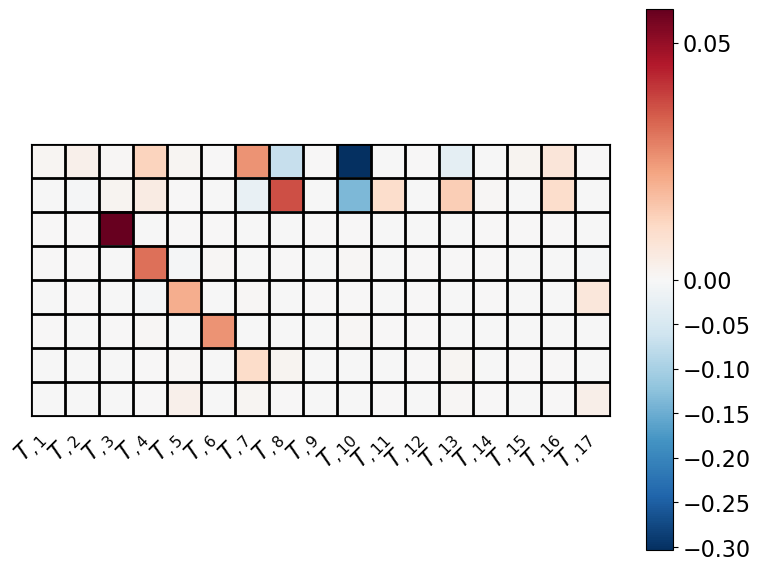

In [21]:
plot_weight(
    proj_mat,
    color=None,
    labels=['$T_{,%s}$' % (i + 1) for i in range(num_inputs)],
    colorbar=True
)

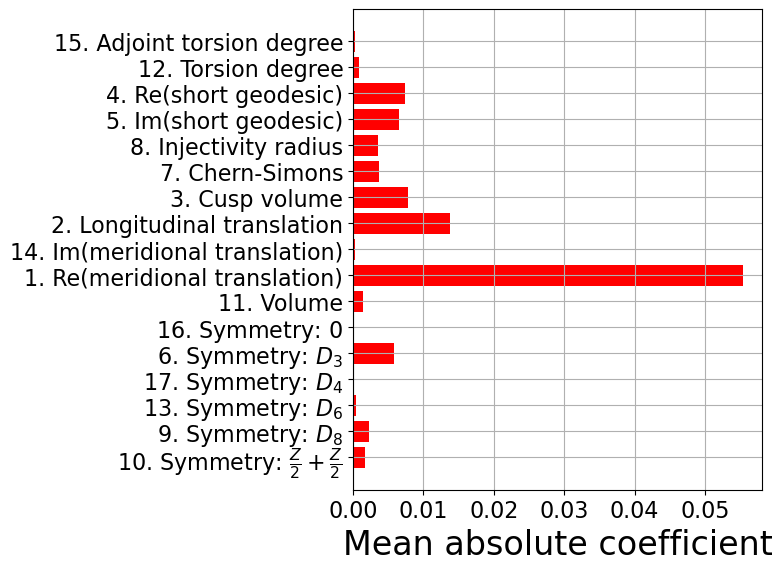

In [22]:
proj_mat_mean = np.mean(abs(proj_mat), axis=0)
plot_mean(
    proj_mat_mean,
    labels=X_labels
)

Top n inputs: 17
Loss: 0.0007239826
Acc: 0.8513640761
Top n inputs: 16
Loss: 0.0007243407
Acc: 0.8497231007
Top n inputs: 15
Loss: 0.0007246387
Acc: 0.8503384590
Top n inputs: 14
Loss: 0.0007245443
Acc: 0.8507282138
Top n inputs: 13
Loss: 0.0007227090
Acc: 0.8493743539
Top n inputs: 12
Loss: 0.0007187018
Acc: 0.8493948579
Top n inputs: 11
Loss: 0.0007322183
Acc: 0.8394461274
Top n inputs: 10
Loss: 0.0007889144
Acc: 0.8267077208
Top n inputs: 9
Loss: 0.0007927918
Acc: 0.8174769282
Top n inputs: 8
Loss: 0.0007901769
Acc: 0.8175384402
Top n inputs: 7
Loss: 0.0007872125
Acc: 0.8225846291
Top n inputs: 6
Loss: 0.0007871532
Acc: 0.8196718097
Top n inputs: 5
Loss: 0.0007888144
Acc: 0.8218051195
Top n inputs: 4
Loss: 0.0007986968
Acc: 0.8169230819
Top n inputs: 3
Loss: 0.0008117763
Acc: 0.8130051494
Top n inputs: 2
Loss: 0.0011186406
Acc: 0.7394051552
Top n inputs: 1
Loss: 0.0032996484
Acc: 0.5785846114


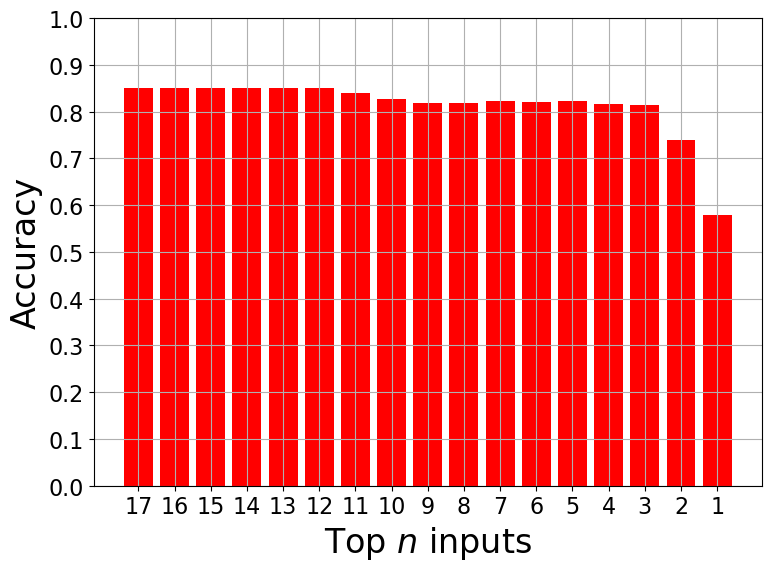

In [ ]:
top_n_acc = []
proj_mat_zero = np.copy(proj_mat)
sort_indices = np.argsort(proj_mat_mean)
for i in range(num_inputs):
    print(f'Top n inputs: {num_inputs - i}')
    proj_mat_zero[:, sort_indices[:i]] = 0.
    (
        preds_test,
        feats_out_test,
        feats_in_test,
        _,
        _,
        _,
        grad_in_test
    ) = model_pnam.predict(
        X_test, y_test, model_idx, weight, proj_mat_zero
    )
    acc = accuracy(
        preds_test,
        y_test * (max_signature - min_signature) / 2,
        num_classes
    )
    print(f'Acc: {acc:.10f}')
    top_n_acc.append(acc)
top_n_acc = np.array(top_n_acc)
plot_top_n_acc(top_n_acc, graph='bar')

In [24]:
weight_zero = np.copy(weight)
weight_zero[abs(weight_zero) < weight_thresh] = 0.
weight_zero_mean = np.mean(abs(weight_zero), axis=0)

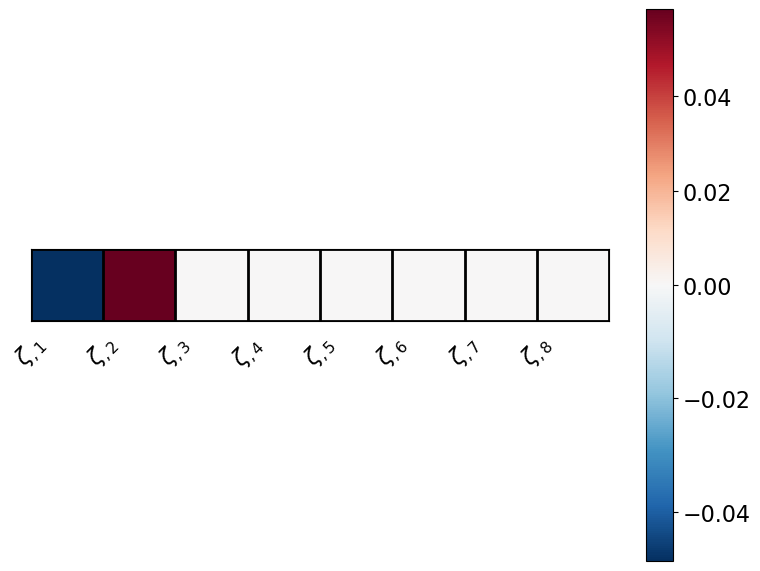

In [ ]:
plot_weight(
    weight_zero,
    color=None,
    labels=[r'$\zeta_{,%s}$' % (i + 1) for i in range(num_networks)],
    colorbar=True
)

In [ ]:
proj_mat_zero = np.copy(proj_mat)
for i in range(proj_size):
    if weight_zero_mean[i] == 0:
        proj_mat_zero[i] = 0.

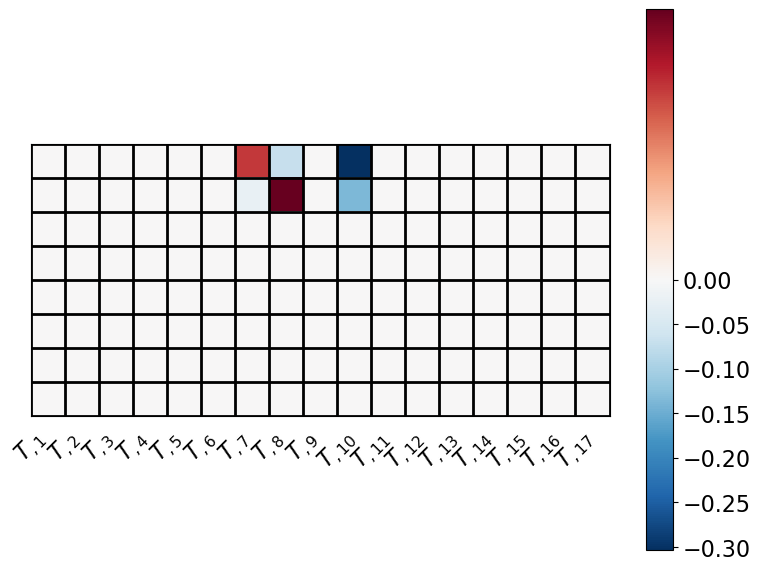

In [27]:
proj_mat_zero[:, sort_indices[:-proj_mat_idx]] = 0.
plot_weight(
    proj_mat_zero,
    color=None,
    labels=['$T_{,%s}$' % (i + 1) for i in range(num_inputs)],
    colorbar=True
)

In [28]:
(
    preds_test, feats_out_test, feats_in_test, _, _, _, grad_in_test
) = model_pnam.predict(
    X_test,
    y_test,
    model_idx,
    weight_zero,
    proj_mat_zero if proj_size > 0 else None
)
acc = accuracy(
    preds_test,
    y_test * (max_signature - min_signature) / 2,
    num_classes
)
print(f'Acc: {acc:.10f}')

Loss: 0.0008117763
Acc: 0.8130051494


In [29]:
num_train_points = X_train.shape[0]
if num_train_points > num_sr_points:
    np.random.seed(random_state)
    sr_indices = np.random.choice(
        num_train_points, num_sr_points, replace=False
    )
    X_sr = X_train[sr_indices]
    y_sr = y_train[sr_indices]
else:
    X_sr = X_train
    y_sr = y_train

In [30]:
(
    preds_sr, feats_out_sr, feats_in_sr, _, _, _, grad_in_sr
) = model_pnam.predict(
    X_sr,
    y_sr,
    model_idx,
    weight_zero,
    proj_mat_zero if proj_size > 0 else None
)
acc = accuracy(
    preds_sr,
    y_sr * (max_signature - min_signature) / 2,
    num_classes
)
print(f'Acc: {acc:.10f}')

Loss: 0.0009011562
Acc: 0.7950000167


In [31]:
model_sr = pysr.PySRRegressor(
    binary_operators=['+', '-', '*'],
    unary_operators=['square'],
    maxsize=30,
    niterations=10000000,
    populations=30,
    population_size=30,
    ncycles_per_iteration=500,
    elementwise_loss='L2DistLoss()',
    model_selection='best',
    timeout_in_seconds=60.,
    output_directory=f'{time}/sr/{model_idx}'
)

In [32]:
g_sr, gp_sr, gpp_sr = train_or_evaluate_all(
    time,
    sobolev,
    model_idx,
    weight_zero,
    feats_out_sr,
    feats_in_sr,
    grad_in_sr,
    feats_out_test,
    feats_in_test,
    grad_in_test,
    model_sr,
    train=False
)

In [33]:
eqs = pd.read_csv(f'{time}/sr/{model_idx}/equations.csv')

output: 1, z: 1
g(z):


$\left(2 z_{1} - 0.65\right) \left(\left(0.22 z_{1} + 0.173\right) \left(- 0.962 z_{1}^{2} + 0.794 z_{1} + 1\right)^{2} - 0.133\right)$

g(x):


$\left(\left(0.096 x_{10} - 0.002 x_{7} + 0.004 x_{8} - 0.237\right) \left(0.267 x_{10} - 0.004 x_{7} + 0.011 x_{8} + 0.119 \left(- x_{10} + 0.016 x_{7} - 0.04 x_{8} + 0.316\right)^{2} - 1\right)^{2} + 0.133\right) \left(0.734 x_{10} - 0.012 x_{7} + 0.029 x_{8} + 0.418\right)$

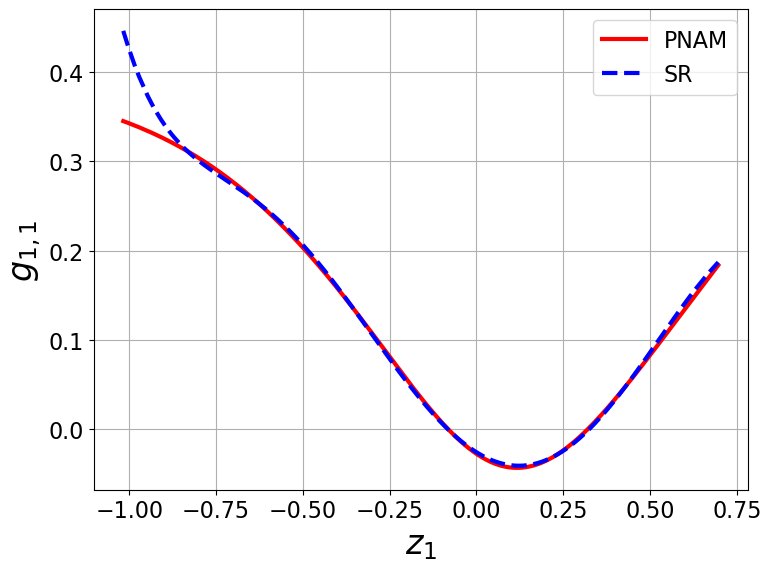

output: 1, z: 2
g(z):


$- 31.141 z_{2}^{2} \left(z_{2}^{2} \left(0.526 z_{2} \left(z_{2} + 1\right)^{2} - 1\right)^{2} + 0.277 z_{2} - 0.419\right)^{2} + \left(z_{2} - 0.248\right)^{2} - 0.018$

g(x):


$0.079 \left(0.589 x_{10} + 0.018 x_{7} - 0.027 x_{8} + 1\right)^{2} - 0.156 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.195\right)^{2} \left(0.107 x_{10} + 0.003 x_{7} - 0.005 x_{8} - 0.064 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.087 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} - 0.165 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.195\right)^{2} + 0.195\right)^{2} + 0.195\right)^{2} + 1\right)^{2} - 0.018$

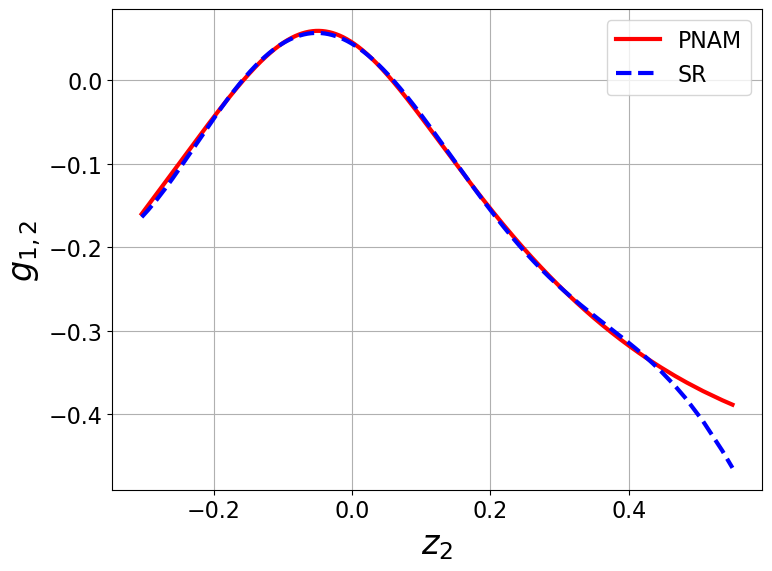

In [34]:
for i in range(num_outputs):
    for j in range(num_networks):
        if weight_zero[i, j] == 0:
            continue

        eq = eqs[(eqs['output'] == i + 1) & (eqs['z'] == j + 1)]
        g_feat = eq['g_sympy'].to_numpy()[0]
        g_input = construct_eq(
            proj_mat_zero if proj_size > 0 else np.eye(num_inputs),
            feat_idx=j,
            g_sympy=g_feat,
            X_scale_=X_std,
            X_mean_=X_mean
        )

        g_feat = sympy.simplify(sympy.sympify(g_feat))
        g_feat = g_feat.replace(
            lambda x: isinstance(x, sympy.Float),
            lambda x: x.round(3)
        )

        g_feat = sympy.latex(g_feat)
        g_input = sympy.latex(g_input)
        print(f'output: {i + 1}, z: {j + 1}')
        print('g(z):')
        display(Markdown(f'${g_feat}$'))
        print('g(x):')
        display(Markdown(f'${g_input}$'))

        plot_g_vs_z(
            feats_in_test,
            feats_out_test,
            g_sr=g_sr if sr else None,
            out_idx=i,
            feat_idx=j,
            prime=False
        )

In [35]:
f = combine_eqs(
    time,
    model_idx,
    weight_zero,
    bias,
    proj_mat_zero if proj_size > 0 else np.eye(num_inputs),
    out_idx=0,
    X_scale_=X_std,
    X_mean_=X_mean,
    y_scale_=[max_signature - min_signature],
    y_mean_=[min_signature]
)
f_latex, f_pred = evaluate_eq(
    X_test.detach().cpu().numpy() * X_std + X_mean,
    weight_zero,
    proj_mat_zero if proj_size > 0 else np.eye(num_inputs),
    out_idx=0,
    eq=f
)
acc = accuracy(
    (f_pred - min_signature) / (max_signature - min_signature),
    y_test * (max_signature - min_signature) / 2,
    num_classes
)
print('output: 1')
print('f(x):')
display(Markdown(f'${f_latex}$'))
print(f'Acc: {acc:.10f}')

output: 1
f(x):


$26 \left(\left(0.096 x_{10} - 0.002 x_{7} + 0.004 x_{8} - 0.237\right) \left(0.267 x_{10} - 0.004 x_{7} + 0.011 x_{8} + 0.119 \left(x_{10} - 0.016 x_{7} + 0.04 x_{8} - 0.316\right)^{2} - 1\right)^{2} + 0.133\right) \left(0.734 x_{10} - 0.012 x_{7} + 0.029 x_{8} + 0.418\right) + 2.054 \left(0.589 x_{10} + 0.018 x_{7} - 0.027 x_{8} + 1\right)^{2} - 4.056 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.195\right)^{2} \left(0.107 x_{10} + 0.003 x_{7} - 0.005 x_{8} - 0.064 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.087 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} - 0.165 \left(x_{10} + 0.031 x_{7} - 0.046 x_{8} + 0.195\right)^{2} + 0.195\right)^{2} + 0.195\right)^{2} + 1\right)^{2} - 0.895$

Acc: 0.8115282059


In [36]:
a = df['longitudinal_translation'].to_numpy()[test_indices]
b = df['meridinal_translation_imag'].to_numpy()[test_indices]
c = df['meridinal_translation_real'].to_numpy()[test_indices]
d = a * c / (2. * (c**2 + b**2))
acc = accuracy(
    (d - min_signature) / (max_signature - min_signature),
    y_test * (max_signature - min_signature) / 2,
    num_classes
)
print(f'Acc: {acc:.10f}')

Acc: 0.7445127964
